# BCS 404: Introduction to Data Science with Python
## Project: Exploratory Data Analysis, Statistical Analysis and Machine Learning on the Titanic Dataset

**Accra Technical University — Department of Computer Science**
**Lecturer:** Dr. Joseph Dadzie
**Academic Year:** 2025/2026, Second Semester

---
**Name:** _Ramseyer Asuah_
**Index Number:** _01258065B_
.
---


## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
%matplotlib inline

pd.set_option('display.max_columns', None)

## Task 1: Data Acquisition

The dataset used in this project is the **Titanic: Machine Learning from Disaster** dataset
(`train.csv`) obtained from Kaggle: https://www.kaggle.com/competitions/titanic/data

It contains demographic and travel information for 891 passengers aboard the RMS Titanic,
along with a binary indicator of whether each passenger survived the sinking.

In [2]:
# Load the dataset
df = pd.read_csv('titanic.csv')

# Dataset dimensions
print("Dataset dimensions (rows, columns):", df.shape)

Dataset dimensions (rows, columns): (891, 12)


In [3]:
# Column names
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
# First five observations
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

**Interpretation:** The dataset has 891 rows and 12 columns. It includes numerical variables
(`Age`, `Fare`, `SibSp`, `Parch`), categorical variables (`Sex`, `Embarked`, `Pclass`), and
identifier/text fields (`PassengerId`, `Name`, `Ticket`, `Cabin`). `Survived` is the target
variable for the machine learning task in Task 5.

## Task 2: Data Cleaning

In [6]:
# Detect missing values
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing_count,
                                 'Missing %': missing_pct})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Observation:** Three columns contain missing values:
- `Cabin` — about 77% missing.
- `Age` — about 20% missing.
- `Embarked` — 2 missing values.

In [7]:
# Detect duplicated observations
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [8]:
# Handle missing values
df_clean = df.copy()

# Age: impute using the median age within each (Pclass, Sex) group.
# This is more informative than a single overall median because age
# strongly relates to passenger class and, to a lesser extent, sex.
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Cabin: drop the column entirely. Roughly 77% of values are missing,
# which is too sparse to impute reliably or to use as a predictor.
df_clean.drop(columns=['Cabin'], inplace=True)

# Embarked: only 2 missing values. Fill with the mode (most frequent
# port of embarkation) since the impact of this choice is negligible.
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Remove duplicates, if any (none were found in this dataset)
df_clean = df_clean.drop_duplicates()

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\nShape after cleaning:", df_clean.shape)

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Shape after cleaning: (891, 11)


**Preprocessing decisions explained:**
1. **Age (median imputation by Pclass and Sex):** Age varies systematically with passenger
   class and sex, so grouped medians preserve this structure better than a single global median.
2. **Cabin (dropped):** With ~77% of values missing, no imputation method would be reliable,
   and the column offers limited direct predictive value in its raw form.
3. **Embarked (mode imputation):** Only 2 records were affected, so the simplest reasonable
   approach — filling with the most common port — has virtually no effect on the overall analysis.
4. **Duplicates:** No fully duplicated rows were found, so no rows were removed at this step.
5. **PassengerId, Name, Ticket** are retained in the cleaned dataframe for reference but are
   excluded from the statistical/ML feature sets later, since they are identifiers rather than
   predictive attributes.

## Task 3: Data Visualisation

### 3.1 Histogram of Passenger Ages

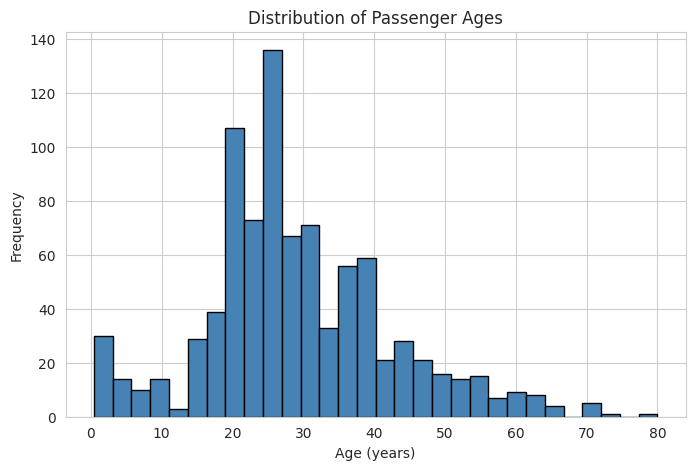

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.show()

**Interpretation:** Passenger ages are right-skewed, with the majority of passengers
between roughly 20 and 40 years old. There is a smaller secondary peak among young children,
and relatively few elderly passengers.

### 3.2 Bar Chart of Passenger Class Distribution

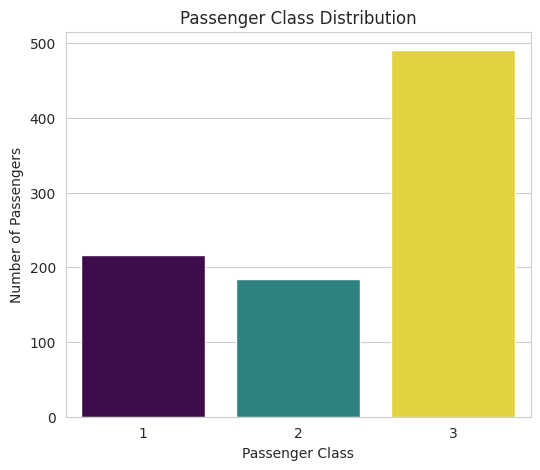

In [10]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df_clean, x='Pclass', palette='viridis', hue='Pclass', legend=False)
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

**Interpretation:** Third class passengers form the largest group, followed by first
class and then second class. This reflects the socio-economic composition of the ship's
passenger list.

### 3.3 Boxplot of Age by Passenger Class

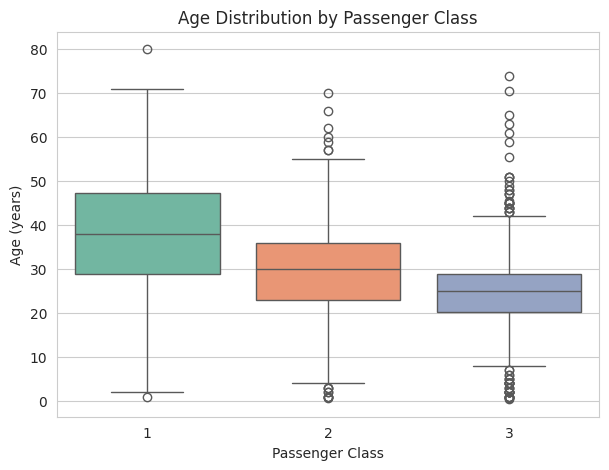

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Pclass', y='Age', hue='Pclass', palette='Set2', legend=False)
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age (years)')
plt.show()

**Interpretation:** Median age decreases from first class to third class, suggesting
that wealthier, first-class passengers tended to be older, while third-class passengers were
generally younger.

### 3.4 Scatter Plot of Age versus Fare

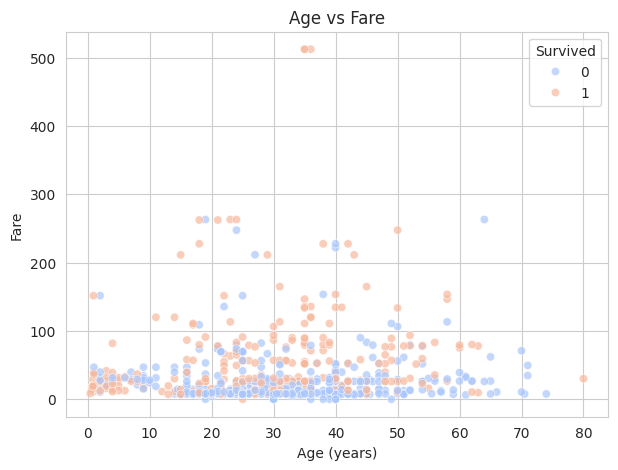

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clean, x='Age', y='Fare', hue='Survived', alpha=0.7, palette='coolwarm')
plt.title('Age vs Fare')
plt.xlabel('Age (years)')
plt.ylabel('Fare')
plt.legend(title='Survived')
plt.show()

**Interpretation:** Most fares are clustered below 100, with a small number of high-fare
outliers. There is no strong linear relationship between age and fare, but passengers who
paid higher fares appear to have a somewhat higher survival rate.

### 3.5 Correlation Heatmap

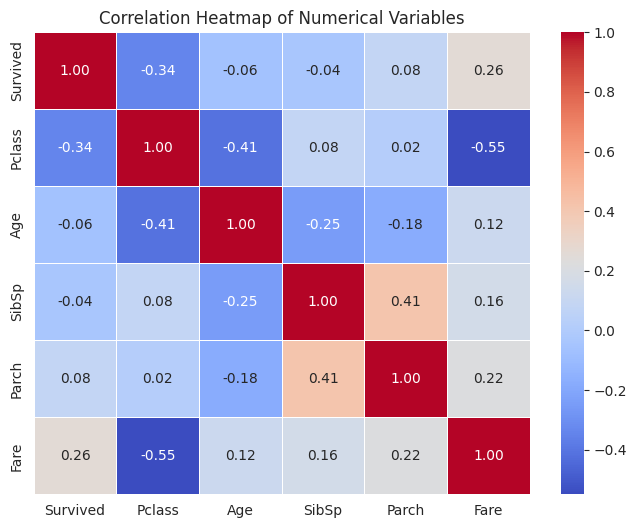

In [13]:
plt.figure(figsize=(8, 6))
numeric_df = df_clean.select_dtypes(include=[np.number]).drop(columns=['PassengerId'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**Interpretation:** `Pclass` and `Fare` show a fairly strong negative correlation,
meaning higher-numbered (lower-status) classes are associated with lower fares. `Fare` and
`Survived` are positively correlated, hinting that passengers who paid more were somewhat
more likely to survive.

### 3.6 Pairplot of Selected Numerical Variables

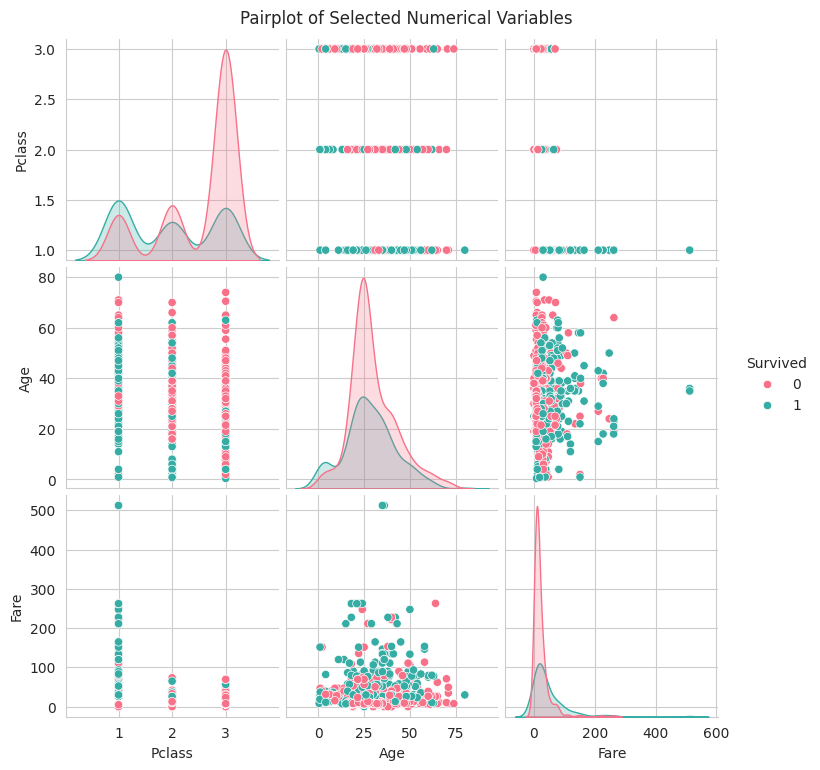

In [14]:
pairplot_vars = ['Survived', 'Pclass', 'Age', 'Fare']
sns.pairplot(df_clean[pairplot_vars], hue='Survived', diag_kind='kde', palette='husl')
plt.suptitle('Pairplot of Selected Numerical Variables', y=1.02)
plt.show()

**Interpretation:** The pairplot reinforces the earlier findings: survivors (orange)
are somewhat concentrated in lower `Pclass` values and higher `Fare` values compared to
non-survivors, while the `Age` distributions of the two groups largely overlap.

## Task 4: Statistical Analysis

### 4.1 Descriptive Statistics

In [15]:
df_clean.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,891.0,NaN,NaN,NaN,29.112424,13.304424,0.42,21.5,26.0,36.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### 4.2 Frequency Distribution

In [16]:
for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(f"--- {col} ---")
    print(df_clean[col].value_counts())
    print(df_clean[col].value_counts(normalize=True).round(3))
    print()

--- Survived ---
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64

--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64
Sex
male      0.648
female    0.352
Name: proportion, dtype: float64

--- Embarked ---
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Embarked
S    0.725
C    0.189
Q    0.086
Name: proportion, dtype: float64



### 4.3 Correlation Analysis

In [17]:
numeric_df = df_clean.select_dtypes(include=[np.number]).drop(columns=['PassengerId'])
corr_matrix = numeric_df.corr()
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.059579,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.413583,0.083081,0.018443,-0.549500
Age,-0.059579,-0.413583,1.000000,-0.249854,-0.175526,0.122692
SibSp,-0.035322,0.083081,-0.249854,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.175526,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.122692,0.159651,0.216225,1.000000


### 4.4 Strongest Positive and Negative Correlations

In [18]:
corr_pairs = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs.sort_values(ascending=False)

print("Strongest positive correlation:")
print(corr_pairs.head(1))

print("\nStrongest negative correlation:")
print(corr_pairs.tail(1))

Strongest positive correlation:
Parch  SibSp    0.414838
dtype: float64

Strongest negative correlation:
Fare  Pclass   -0.5495
dtype: float64


**Results:**
- **Strongest positive correlation:** `SibSp` and `Parch` (≈ 0.41) — passengers travelling
  with siblings/spouses also tended to travel with parents/children, i.e. as family units.
- **Strongest negative correlation:** `Pclass` and `Fare` (≈ -0.55) — as passenger class number
  increases (i.e. moving from 1st to 3rd class), fare paid decreases substantially.

### 4.5 Three Important Statistical Findings

1. **Sex was strongly associated with survival.** About 74% of female passengers survived,
   compared to only about 19% of male passengers — consistent with a "women and children
   first" evacuation policy.
2. **Passenger class was strongly associated with survival.** Survival rate declined from
   about 63% in first class, to 47% in second class, to 24% in third class, indicating that
   socio-economic status affected access to lifeboats.
3. **Fare and passenger class were closely linked to each other and to survival.** Higher
   fares (associated with higher class) corresponded to higher survival rates, while `Age`
   showed only a weak relationship with survival.

## Task 5: Machine Learning — Predicting Survival

### 5.1 Feature Selection

The following predictors are used to build a Logistic Regression classifier for `Survived`:
`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, and `Embarked` (one-hot encoded). These
were chosen because Task 3 and Task 4 showed each has a meaningful relationship with survival,
while identifier fields (`PassengerId`, `Name`, `Ticket`) carry no predictive signal.

In [19]:
ml_df = df_clean.copy()

# Encode categorical variables
ml_df['Sex'] = ml_df['Sex'].map({'male': 0, 'female': 1})
ml_df = pd.get_dummies(ml_df, columns=['Embarked'], drop_first=True)

feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
X = ml_df[feature_cols]
y = ml_df['Survived']

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,True
4,3,0,35.0,0,0,8.0500,False,True


### 5.2 Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (712, 8)
Testing set size: (179, 8)


### 5.3 Train the Logistic Regression Classifier

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model coefficients:")
for feature, coef in zip(feature_cols, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

Model coefficients:
  Pclass: -1.1915
  Sex: 2.5382
  Age: -0.0437
  SibSp: -0.2680
  Parch: -0.0676
  Fare: 0.0021
  Embarked_Q: 0.2281
  Embarked_S: -0.3474


### 5.4 Predict on the Test Set

In [22]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

### 5.5 Model Evaluation

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.8156 (81.56%)


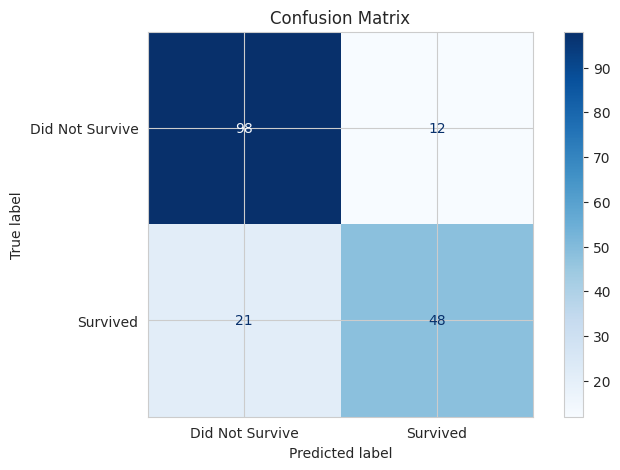

In [24]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [25]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

Classification Report:

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.89      0.86       110
       Survived       0.80      0.70      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      0.79      0.80       179
   weighted avg       0.81      0.82      0.81       179



### 5.6 Discussion of Model Performance

The Logistic Regression model achieved an accuracy of approximately **81.6%** on the held-out
test set. From the confusion matrix, the model correctly identified 98 of 110 non-survivors and
48 of 69 survivors, giving a recall of about 0.70 for the survivor class versus 0.89 for the
non-survivor class — the model is somewhat better at identifying passengers who did not survive
than those who did. This is common in Titanic-style classification tasks, since non-survivors
are the majority class and survival itself depended on factors (e.g. lifeboat allocation, luck)
not fully captured by the available features. Overall, `Sex` and `Pclass` are the strongest
predictors, consistent with the statistical findings in Task 4.

## Task 6: Discussion and Conclusion

### Major Findings
This project analysed the Titanic passenger dataset (891 records, 12 original variables) to
understand the factors associated with survival aboard the RMS Titanic. Exploratory analysis
showed that passengers were predominantly young to middle-aged adults, concentrated in third
class, with fare and class strongly linked to one another.

### Statistical Insights
Correlation analysis identified `Pclass` and `Fare` as the most strongly (negatively) related
pair of numerical variables, while `SibSp` and `Parch` showed the strongest positive
relationship, reflecting family travel groups. Survival was clearly stratified by both sex
(74% of women survived versus 19% of men) and passenger class (63% in first class versus 24%
in third class), pointing to both social norms around evacuation priority and unequal access
to lifeboats by class.

### Machine Learning Results
A Logistic Regression classifier trained on seven predictors (`Pclass`, `Sex`, `Age`, `SibSp`,
`Parch`, `Fare`, `Embarked`) achieved approximately 81.6% accuracy on unseen test data, with
stronger performance in identifying non-survivors (recall ≈ 0.89) than survivors (recall ≈
0.70). This performance gap is consistent with the class imbalance in the dataset (about 62%
non-survivors versus 38% survivors) and with survival outcomes depending partly on
unobservable or unrecorded factors, such as a passenger's exact cabin location or split-second
decisions during the evacuation.

### Limitations of the Study
- The dataset is limited to 891 of the roughly 2,224 passengers and crew aboard the Titanic,
  so results may not generalise to the full population.
- Missing `Age` values were imputed using group medians, which is a reasonable approximation
  but introduces some uncertainty compared to true recorded ages.
- The `Cabin` column, which could have offered useful information about a passenger's physical
  location on the ship, was dropped due to a high proportion of missing values.
- Logistic Regression is a linear model and may not capture more complex, non-linear
  interactions between predictors (e.g. between age and class) as effectively as more flexible
  models such as Random Forests or Gradient Boosting.

### Recommendations
- Future work could explore imputing `Cabin` deck information rather than dropping it
  entirely, since cabin location may relate to speed of access to lifeboats.
- Alternative or additional models (e.g. Random Forest, Support Vector Machines, or Gradient
  Boosting) could be compared against Logistic Regression to check whether accuracy and
  survivor recall improve.
- Techniques for handling class imbalance (e.g. class weighting or resampling) could be applied
  to improve recall on the minority (survivor) class.
- Feature engineering — such as extracting titles (Mr., Mrs., Miss, Master) from the `Name`
  column, or creating a family-size feature from `SibSp` and `Parch` — could further improve
  model performance.
